# Time Series Analysis Assignment: Forecasting Stock Prices with ARIMA and GARCH Models



## Task 1: Environment Setup

Install required packages

In [1]:
# Install required packages
import subprocess
import sys

packages = ['pandas', 'numpy', 'matplotlib', 'statsmodels', 'arch', 'pmdarima', 'scipy']

for package in packages:
    try:
        __import__(package)
        print(f'{package} is already installed')
    except ImportError:
        print(f'Installing {package}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

print('\nAll required packages installed successfully!')

pandas is already installed
numpy is already installed
matplotlib is already installed
statsmodels is already installed
arch is already installed
pmdarima is already installed
scipy is already installed

All required packages installed successfully!


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import warnings
warnings.filterwarnings('ignore')

from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import os

# Create plots directory if it doesn't exist
os.makedirs('../plots', exist_ok=True)
os.makedirs('../report', exist_ok=True)

print('All libraries imported successfully!')

All libraries imported successfully!


## Task 2: Data Loading and Exploration

In [3]:
# Load the data
data = pd.read_csv('../apple_stock_data.csv')

# Display basic information
print('Dataset Shape:', data.shape)
print('\nFirst few rows:')
print(data.head())
print('\nData Info:')
print(data.info())
print('\nBasic Statistics:')
print(data.describe())

Dataset Shape: (2580, 6)

First few rows:
           Date    Open    High     Low   Close     Volume
0   Apr 4, 2025  193.89  199.88  187.34  188.38  125569000
1   Apr 3, 2025  205.54  207.49  201.25  203.19  103419000
2   Apr 2, 2025  221.32  225.19  221.02  223.89   35905900
3   Apr 1, 2025  219.81  223.68  218.90  223.19   36412700
4  Mar 31, 2025  217.01  225.62  216.23  222.13   65299300

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2580 non-null   str    
 1   Open    2580 non-null   float64
 2   High    2580 non-null   float64
 3   Low     2580 non-null   float64
 4   Close   2580 non-null   float64
 5   Volume  2580 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 121.1 KB
None

Basic Statistics:
              Open         High          Low        Close        Volume
count  2580.000000  2580.000000  2580.000000 

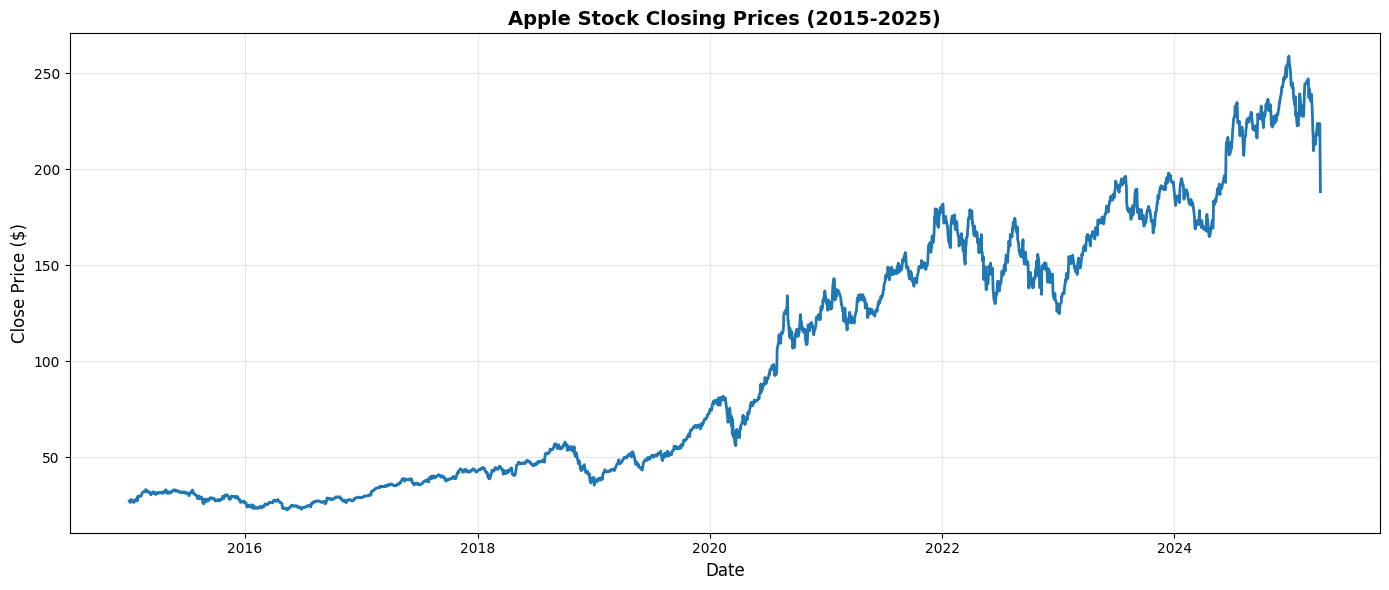

Closing prices plot saved!


In [4]:
# Plot the closing prices over time
plt.figure(figsize=(14, 6))
data['Date'] = pd.to_datetime(data['Date'])
data_sorted = data.sort_values('Date')
plt.plot(data_sorted['Date'], data_sorted['Close'], linewidth=2, color='#1f77b4')
plt.title('Apple Stock Closing Prices (2015-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/closing_prices_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print('Closing prices plot saved!')

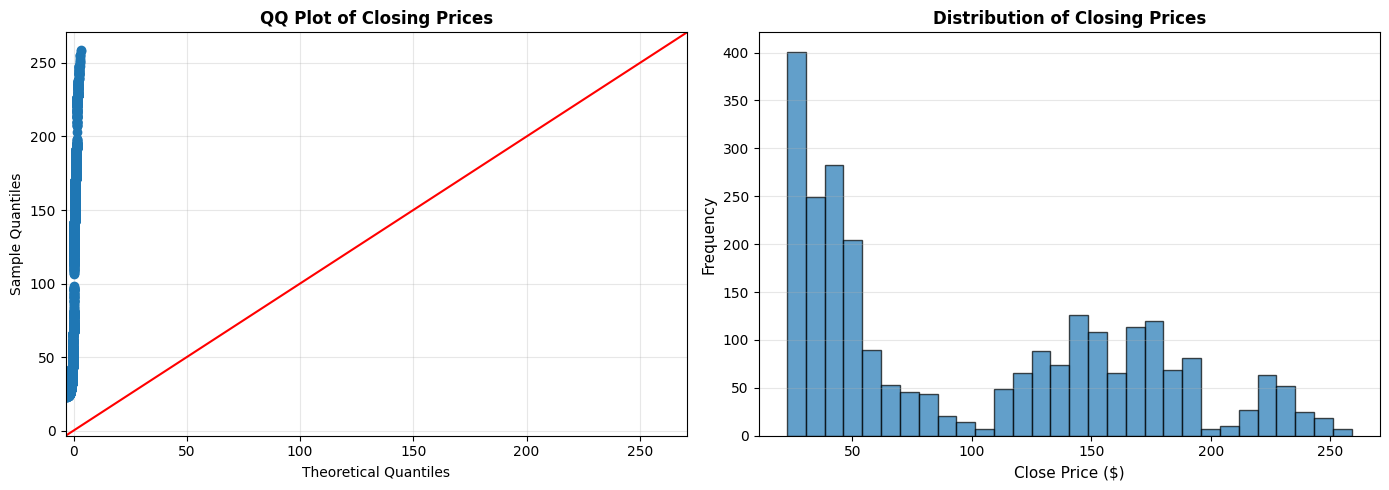

QQ plot and histogram saved!


In [5]:
#  QQ plot to assess normality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# QQ plot of closing prices
qqplot(data_sorted['Close'], line='45', ax=axes[0])
axes[0].set_title('QQ Plot of Closing Prices', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Histogram of closing prices
axes[1].hist(data_sorted['Close'], bins=30, edgecolor='black', alpha=0.7, color='#1f77b4')
axes[1].set_title('Distribution of Closing Prices', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Close Price ($)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../plots/qq_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print('QQ plot and histogram saved!')

In [6]:
# Trend and anomaly analysis
print('\n=== DATA EXPLORATION ANALYSIS ===' )
print('\nClosing Price Statistics:')
print(f'Min Price: ${data_sorted["Close"].min():.2f}')
print(f'Max Price: ${data_sorted["Close"].max():.2f}')
print(f'Mean Price: ${data_sorted["Close"].mean():.2f}')
print(f'Std Dev: ${data_sorted["Close"].std():.2f}')

# Calculate returns
data_sorted['Daily_Return'] = data_sorted['Close'].pct_change() * 100
print(f'\nDaily Returns Statistics:')
print(f'Mean Daily Return: {data_sorted["Daily_Return"].mean():.4f}%')
print(f'Std Dev Daily Return: {data_sorted["Daily_Return"].std():.4f}%')
print(f'Max Daily Gain: {data_sorted["Daily_Return"].max():.4f}%')
print(f'Max Daily Loss: {data_sorted["Daily_Return"].min():.4f}%')

# Trend observation
price_change = data_sorted['Close'].iloc[-1] - data_sorted['Close'].iloc[0]
price_change_pct = (price_change / data_sorted['Close'].iloc[0]) * 100
print(f'\nOverall Price Change: ${price_change:.2f} ({price_change_pct:.2f}%)')

# Check for missing values
print(f'\nMissing Values:')
print(data_sorted.isnull().sum())


=== DATA EXPLORATION ANALYSIS ===

Closing Price Statistics:
Min Price: $22.58
Max Price: $259.02
Mean Price: $99.69
Std Dev: $67.75

Daily Returns Statistics:
Mean Daily Return: 0.0912%
Std Dev Daily Return: 1.8084%
Max Daily Gain: 11.9723%
Max Daily Loss: -12.8652%

Overall Price Change: $161.05 (589.28%)

Missing Values:
Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Daily_Return    1
dtype: int64


## Task 3: Time Series Object Creation and Data Preparation

In [7]:
# Prepare the data as a time series object
# Convert Date to datetime (already done above)
data_ts = data_sorted.copy()
data_ts['Date'] = pd.to_datetime(data_ts['Date'])

# Set Date as index
data_ts.set_index('Date', inplace=True)

# Set business day frequency (stocks trade on business days)
data_ts = data_ts.asfreq('B')

# Handle missing values using interpolation
data_ts['Close'] = data_ts['Close'].interpolate(method='linear')
data_ts['Open'] = data_ts['Open'].interpolate(method='linear')
data_ts['High'] = data_ts['High'].interpolate(method='linear')
data_ts['Low'] = data_ts['Low'].interpolate(method='linear')
data_ts['Volume'] = data_ts['Volume'].interpolate(method='linear')

print('Time Series Data Shape:', data_ts.shape)
print('\nIndex:', data_ts.index.name)
print('Frequency:', data_ts.index.freq)
print('\nFirst few rows:')
print(data_ts.head())
print('\nLast few rows:')
print(data_ts.tail())

Time Series Data Shape: (2676, 6)

Index: Date
Frequency: <BusinessDay>

First few rows:
             Open   High    Low  Close       Volume  Daily_Return
Date                                                             
2015-01-02  27.85  27.86  26.84  27.33  212818400.0           NaN
2015-01-05  27.07  27.16  26.35  26.56  257142000.0     -2.817417
2015-01-06  26.64  26.86  26.16  26.57  263188400.0      0.037651
2015-01-07  26.80  27.05  26.67  26.94  160423600.0      1.392548
2015-01-08  27.31  28.04  27.17  27.97  237458000.0      3.823311

Last few rows:
              Open    High     Low   Close       Volume  Daily_Return
Date                                                                 
2025-03-31  217.01  225.62  216.23  222.13   65299300.0      1.941257
2025-04-01  219.81  223.68  218.90  223.19   36412700.0      0.477198
2025-04-02  221.32  225.19  221.02  223.89   35905900.0      0.313634
2025-04-03  205.54  207.49  201.25  203.19  103419000.0     -9.245612
2025-04-04  1

In [8]:
# Split into training (80%) and testing (20%) sets
train_size = int(len(data_ts) * 0.8)
train_data = data_ts[:train_size]
test_data = data_ts[train_size:]

print(f'Training Set Size: {len(train_data)} observations')
print(f'Testing Set Size: {len(test_data)} observations')
print(f'Training Period: {train_data.index[0].date()} to {train_data.index[-1].date()}')
print(f'Testing Period: {test_data.index[0].date()} to {test_data.index[-1].date()}')

Training Set Size: 2140 observations
Testing Set Size: 536 observations
Training Period: 2015-01-02 to 2023-03-16
Testing Period: 2023-03-17 to 2025-04-04


## Task 4: Model Fitting and Analysis
### Part A: ARIMA Model

In [9]:
# Test for stationarity using Augmented Dickey-Fuller (ADF) test
print('\n=== STATIONARITY TEST (ADF Test) ===' )
print('\nTesting closing prices:') 
result_original = adfuller(train_data['Close'].dropna())
print(f'ADF Statistic: {result_original[0]:.6f}')
print(f'P-value: {result_original[1]:.6f}')
print(f'Critical Values:')
for key, value in result_original[4].items():
    print(f'  {key}: {value:.3f}')

if result_original[1] <= 0.05:
    print('\nResult: The series is STATIONARY (p-value <= 0.05)')
    d_param = 0
else:
    print('\nResult: The series is NON-STATIONARY (p-value > 0.05)')
    print('Applying first differencing...')
    d_param = 1
    
    # Test differenced series
    diff_series = train_data['Close'].diff().dropna()
    print('\nTesting first differenced series:')
    result_diff = adfuller(diff_series)
    print(f'ADF Statistic: {result_diff[0]:.6f}')
    print(f'P-value: {result_diff[1]:.6f}')
    if result_diff[1] <= 0.05:
        print('Result: First differenced series is STATIONARY')


=== STATIONARITY TEST (ADF Test) ===

Testing closing prices:


ADF Statistic: -0.189654
P-value: 0.939744
Critical Values:
  1%: -3.433
  5%: -2.863
  10%: -2.567

Result: The series is NON-STATIONARY (p-value > 0.05)
Applying first differencing...

Testing first differenced series:
ADF Statistic: -14.798759
P-value: 0.000000
Result: First differenced series is STATIONARY


In [10]:
# Fit ARIMA model using auto_arima
print('\n=== AUTO ARIMA MODEL FITTING ===' )
print('Testing different ARIMA parameters...')
print('This may take a moment...\n')

arima_model = auto_arima(
    train_data['Close'],
    start_p=0,
    start_q=0,
    start_d=d_param,
    max_p=5,
    max_q=5,
    max_d=2,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(f'\n\nBest ARIMA Model: {arima_model.order}')
print('\n' + '='*50)
print(arima_model.summary())


=== AUTO ARIMA MODEL FITTING ===
Testing different ARIMA parameters...
This may take a moment...

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=8452.329, Time=0.17 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=8450.272, Time=0.28 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=8449.939, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8452.868, Time=0.13 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=8449.425, Time=1.09 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=8450.512, Time=1.35 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=8450.628, Time=1.10 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=8448.974, Time=0.60 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=8450.098, Time=0.51 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=8451.913, Time=1.80 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=8449.988, Time=0.20 sec

Best model:  ARIMA(0,1,2)(0,0,0)[0] intercept
Total fit time: 7.563 seconds


Best ARIMA Model: (0, 1, 2)

                        

In [11]:
# Make forecasts for the next 30 days
forecast_steps = 30
forecast_arima, conf_int = arima_model.predict(n_periods=forecast_steps, return_conf_int=True)
conf_int = pd.DataFrame(conf_int, columns=['Lower_CI', 'Upper_CI'])

# Create forecast dataframe
forecast_index = pd.date_range(start=train_data.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='B')
forecast_df = pd.DataFrame({
    'Forecast': forecast_arima,
    'Lower_CI': conf_int.iloc[:, 0],
    'Upper_CI': conf_int.iloc[:, 1]
}, index=forecast_index)

print('\n=== ARIMA FORECASTS (Next 30 Days) ===' )
print(forecast_df.head(10))
print('\n...')
print(forecast_df.tail(5))


=== ARIMA FORECASTS (Next 30 Days) ===
              Forecast  Lower_CI  Upper_CI
2023-03-17  155.755702       NaN       NaN
2023-03-20  155.709857       NaN       NaN
2023-03-21  155.769844       NaN       NaN
2023-03-22  155.829832       NaN       NaN
2023-03-23  155.889820       NaN       NaN
2023-03-24  155.949807       NaN       NaN
2023-03-27  156.009795       NaN       NaN
2023-03-28  156.069783       NaN       NaN
2023-03-29  156.129770       NaN       NaN
2023-03-30  156.189758       NaN       NaN

...
              Forecast  Lower_CI  Upper_CI
2023-04-21  157.149560       NaN       NaN
2023-04-24  157.209548       NaN       NaN
2023-04-25  157.269535       NaN       NaN
2023-04-26  157.329523       NaN       NaN
2023-04-27  157.389510       NaN       NaN


In [12]:
# Check residuals for white noise properties
residuals = arima_model.resid()

print('\n=== RESIDUAL DIAGNOSTICS ===' )
print(f'Mean of Residuals: {residuals.mean():.6f}')
print(f'Std Dev of Residuals: {residuals.std():.6f}')
print(f'Min Residual: {residuals.min():.6f}')
print(f'Max Residual: {residuals.max():.6f}')


=== RESIDUAL DIAGNOSTICS ===
Mean of Residuals: 0.012716
Std Dev of Residuals: 1.837619
Min Residual: -10.502517
Max Residual: 27.270012


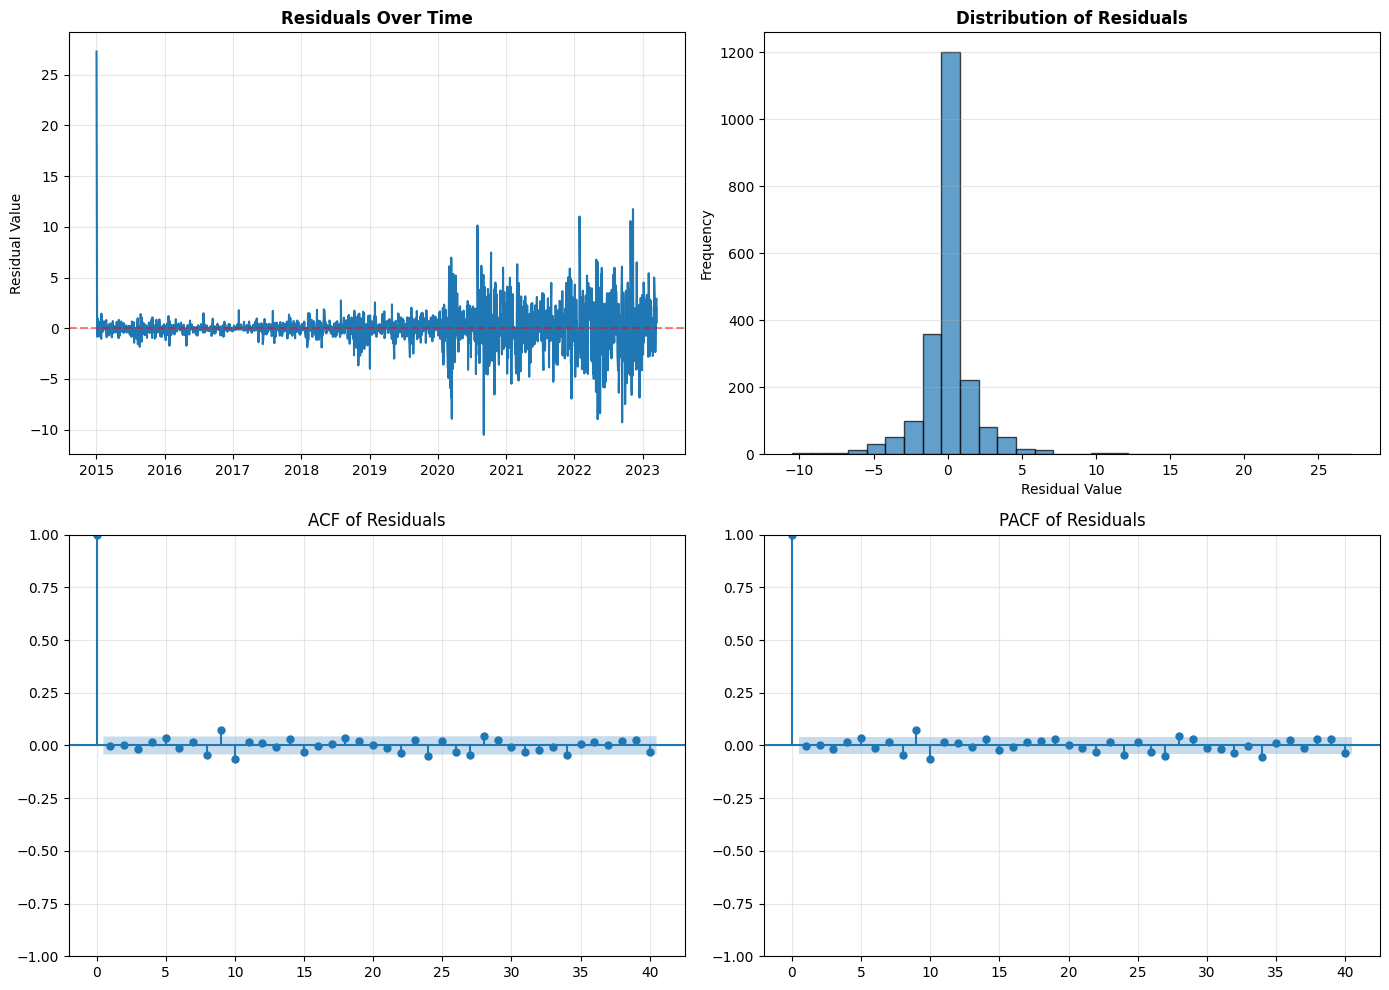

Residual diagnostics plot saved!


In [13]:
# Plot ACF and PACF of residuals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals plot
axes[0, 0].plot(residuals, color='#1f77b4')
axes[0, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Residuals Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Residual Value')
axes[0, 0].grid(True, alpha=0.3)

# Histogram of residuals
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='#1f77b4')
axes[0, 1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Residual Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# ACF plot
plot_acf(residuals, lags=40, ax=axes[1, 0], title='ACF of Residuals')
axes[1, 0].grid(True, alpha=0.3)

# PACF plot  
plot_pacf(residuals, lags=40, ax=axes[1, 1], title='PACF of Residuals')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/arima_residuals_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print('Residual diagnostics plot saved!')

### Part B: GARCH Model

In [14]:
# Compute daily returns from closing prices
returns = train_data['Close'].pct_change().dropna() * 100  # Convert to percentage

print('\n=== DAILY RETURNS ANALYSIS ===' )
print(f'Number of Returns: {len(returns)}')
print(f'Mean Daily Return: {returns.mean():.6f}%')
print(f'Std Dev (Volatility): {returns.std():.6f}%')
print(f'Skewness: {returns.skew():.6f}')
print(f'Kurtosis: {returns.kurtosis():.6f}')
print(f'Min Return: {returns.min():.6f}%')
print(f'Max Return: {returns.max():.6f}%')


=== DAILY RETURNS ANALYSIS ===
Number of Returns: 2139
Mean Daily Return: 0.098175%
Std Dev (Volatility): 1.830410%
Skewness: -0.013509
Kurtosis: 5.429133
Min Return: -12.865160%
Max Return: 11.972285%


In [15]:
# Fit GARCH(1,1) model
print('\n=== GARCH(1,1) MODEL FITTING ===' )

garch_model_11 = arch_model(returns, vol='Garch', p=1, q=1)
garch_fit_11 = garch_model_11.fit(disp='off')

print(garch_fit_11.summary())


=== GARCH(1,1) MODEL FITTING ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4106.30
Distribution:                  Normal   AIC:                           8220.60
Method:            Maximum Likelihood   BIC:                           8243.27
                                        No. Observations:                 2139
Date:                Fri, Apr 24 2026   Df Residuals:                     2138
Time:                        00:18:22   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.1757  3.558e-02    

In [16]:
# Fit GARCH(2,2) model for comparison
print('\n=== GARCH(2,2) MODEL FITTING ===' )

garch_model_22 = arch_model(returns, vol='Garch', p=2, q=2)
garch_fit_22 = garch_model_22.fit(disp='off')

print(garch_fit_22.summary())


=== GARCH(2,2) MODEL FITTING ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4106.10
Distribution:                  Normal   AIC:                           8224.20
Method:            Maximum Likelihood   BIC:                           8258.21
                                        No. Observations:                 2139
Date:                Fri, Apr 24 2026   Df Residuals:                     2138
Time:                        00:18:23   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.1751  3.572e-02    

In [17]:
# Compare GARCH models
print('\n=== GARCH MODELS COMPARISON ===' )
print(f'\nGARCH(1,1) AIC: {garch_fit_11.aic:.2f}')
print(f'GARCH(2,2) AIC: {garch_fit_22.aic:.2f}')
print(f'\nGARCH(1,1) BIC: {garch_fit_11.bic:.2f}')
print(f'GARCH(2,2) BIC: {garch_fit_22.bic:.2f}')

# Use GARCH(1,1) as it typically performs well
best_garch_fit = garch_fit_11
print('\nBest Model Selected: GARCH(1,1) (standard choice for asset returns)')


=== GARCH MODELS COMPARISON ===

GARCH(1,1) AIC: 8220.60
GARCH(2,2) AIC: 8224.20

GARCH(1,1) BIC: 8243.27
GARCH(2,2) BIC: 8258.21

Best Model Selected: GARCH(1,1) (standard choice for asset returns)


In [18]:
# Extract conditional volatility
conditional_volatility = best_garch_fit.conditional_volatility

# Forecast volatility for next 30 days
garch_forecast = best_garch_fit.forecast(horizon=forecast_steps)
garch_volatility_forecast = np.sqrt(garch_forecast.variance.values[-1, :])

print(f'\n=== GARCH VOLATILITY FORECAST ===' )
print(f'Current Volatility: {conditional_volatility.iloc[-1]:.6f}%')
print(f'\nForecasted Volatility (Next 30 Days):')
for i, vol in enumerate(garch_volatility_forecast[:5], 1):
    print(f'  Day {i}: {vol:.6f}%')
print('  ...')
for i, vol in enumerate(garch_volatility_forecast[-3:], forecast_steps-2):
    print(f'  Day {i}: {vol:.6f}%')


=== GARCH VOLATILITY FORECAST ===
Current Volatility: 1.498951%

Forecasted Volatility (Next 30 Days):
  Day 1: 1.541562%
  Day 2: 1.556835%
  Day 3: 1.571305%
  Day 4: 1.585020%
  Day 5: 1.598028%
  ...
  Day 28: 1.771018%
  Day 29: 1.775029%
  Day 30: 1.778857%


## Task 5: Forecasting and Reporting

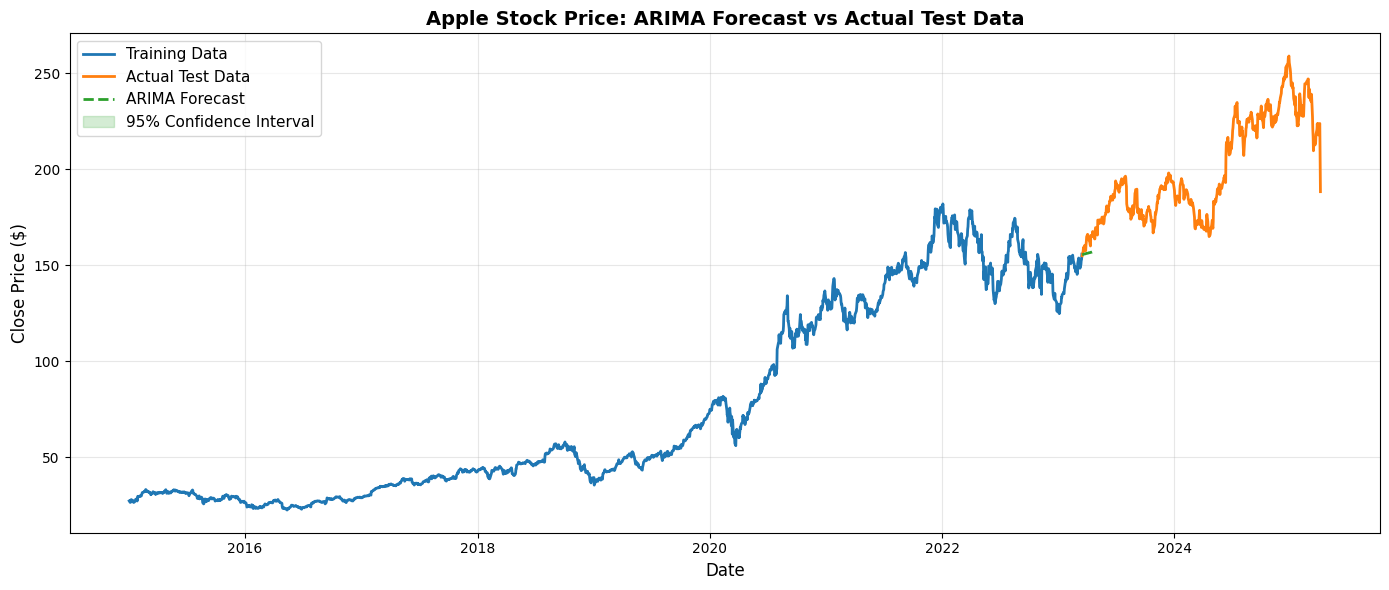

Forecast plot saved!


In [19]:
# Plot ARIMA forecasts against actual test data
fig, ax = plt.subplots(figsize=(14, 6))

# Plot training data
ax.plot(train_data.index, train_data['Close'], label='Training Data', color='#1f77b4', linewidth=2)

# Plot test data
ax.plot(test_data.index, test_data['Close'], label='Actual Test Data', color='#ff7f0e', linewidth=2)

# Plot forecast
ax.plot(forecast_df.index, forecast_df['Forecast'], label='ARIMA Forecast', color='#2ca02c', linewidth=2, linestyle='--')

# Plot confidence interval
ax.fill_between(forecast_df.index, 
                  forecast_df['Lower_CI'], 
                  forecast_df['Upper_CI'], 
                  color='#2ca02c', alpha=0.2, label='95% Confidence Interval')

ax.set_title('Apple Stock Price: ARIMA Forecast vs Actual Test Data', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Close Price ($)', fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/forecast_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print('Forecast plot saved!')

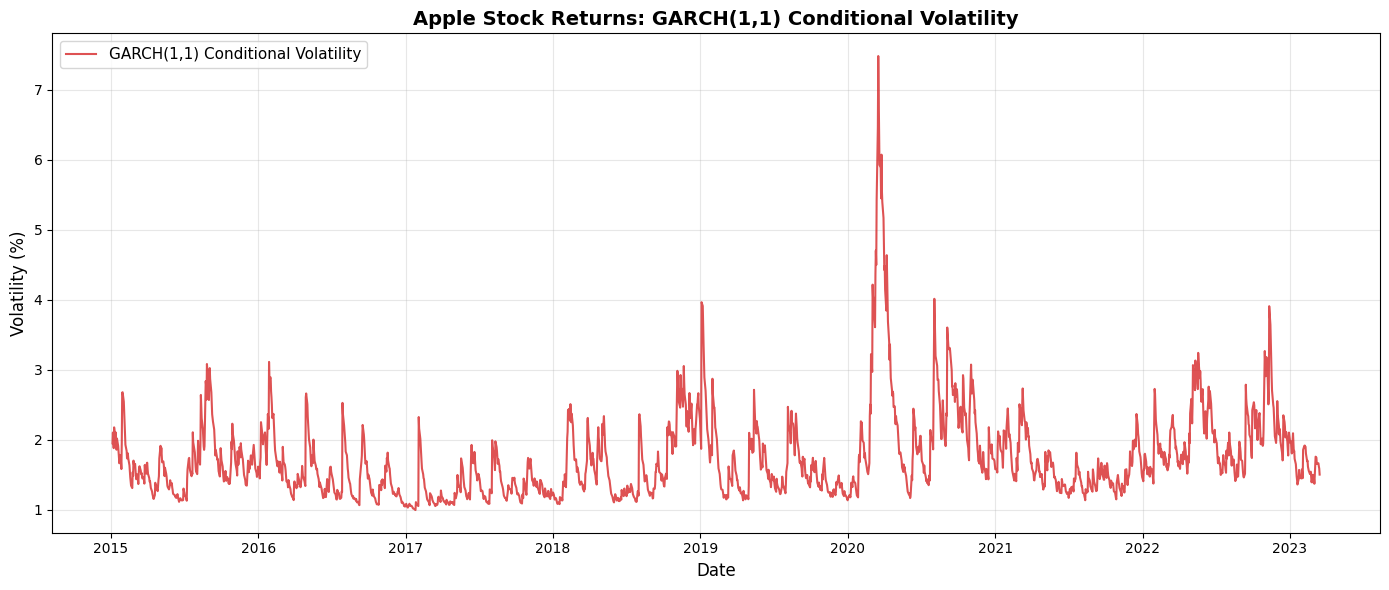

Volatility plot saved!


In [20]:
# Plot volatility estimates from GARCH model
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
        conditional_volatility.index,
        conditional_volatility,
        label='GARCH(1,1) Conditional Volatility',
        color='#d62728',
        linewidth=1.5,
        alpha=0.8
)

ax.set_title('Apple Stock Returns: GARCH(1,1) Conditional Volatility', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volatility (%)', fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/volatility_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print('Volatility plot saved!')

In [21]:
# Calculate forecast accuracy metrics
# Only compare with actual test data for the forecast period
actual_test = test_data['Close'].iloc[:forecast_steps]
forecast_values = forecast_df['Forecast'][:len(actual_test)]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(actual_test, forecast_values))

# Calculate MAPE
mape = mean_absolute_percentage_error(actual_test, forecast_values)

# Calculate MAE
mae = np.mean(np.abs(actual_test - forecast_values))

# Calculate directional accuracy
actual_direction = np.sign(np.diff(actual_test.values))
forecast_direction = np.sign(np.diff(forecast_values.values))
directional_accuracy = np.sum(actual_direction == forecast_direction) / len(actual_direction) * 100

print('\n=== FORECAST ACCURACY METRICS ===' )
print(f'\nRoot Mean Squared Error (RMSE): ${rmse:.4f}')
print(f'Mean Absolute Error (MAE): ${mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')
print(f'Directional Accuracy: {directional_accuracy:.2f}%')


=== FORECAST ACCURACY METRICS ===

Root Mean Squared Error (RMSE): $6.9283
Mean Absolute Error (MAE): $6.2667
Mean Absolute Percentage Error (MAPE): 0.0381%
Directional Accuracy: 48.28%


In [22]:
# Create a comprehensive comparison table
comparison_data = pd.DataFrame({
    'Date': actual_test.index,
    'Actual_Price': actual_test.values,
    'Forecast_Price': forecast_values.values,
    'Error': actual_test.values - forecast_values.values,
    'Pct_Error': ((actual_test.values - forecast_values.values) / actual_test.values * 100)
})

print('\n=== FORECAST COMPARISON (First 10 Days) ===' )
print(comparison_data.head(10).to_string(index=False))


=== FORECAST COMPARISON (First 10 Days) ===
      Date  Actual_Price  Forecast_Price     Error  Pct_Error
2023-03-17        155.00      155.755702 -0.755702  -0.487549
2023-03-20        157.40      155.709857  1.690143   1.073789
2023-03-21        159.28      155.769844  3.510156   2.203764
2023-03-22        157.83      155.829832  2.000168   1.267293
2023-03-23        158.93      155.889820  3.040180   1.912905
2023-03-24        160.25      155.949807  4.300193   2.683428
2023-03-27        158.28      156.009795  2.270205   1.434297
2023-03-28        157.65      156.069783  1.580217   1.002358
2023-03-29        160.77      156.129770  4.640230   2.886254
2023-03-30        162.36      156.189758  6.170242   3.800346


## Task 6: Bonus Task (Optional) - SARIMAX Model

In [23]:
# Optional: Fit SARIMAX model
from statsmodels.tsa.statespace.sarimax import SARIMAX

print('\n=== SARIMAX MODEL (BONUS) ===' )
print('Fitting SARIMAX model with seasonal parameters...')

try:
    # Fit SARIMAX with seasonal parameters
    sarimax_model = SARIMAX(
        train_data['Close'],
        order=(1, 1, 1),  # (p, d, q)
        seasonal_order=(1, 1, 1, 5)  # (P, D, Q, s) - 5 trading days
    )
    sarimax_fit = sarimax_model.fit(disp=False)
    
    # Make forecast
    sarimax_forecast = sarimax_fit.get_forecast(steps=forecast_steps).predicted_mean
    
    print('\nSARIMAX Model Summary:')
    print(sarimax_fit.summary())
    
    # Compare forecasts
    print('\n=== MODEL COMPARISON ===' )
    
    sarimax_rmse = np.sqrt(mean_squared_error(actual_test, sarimax_forecast[:len(actual_test)]))
    sarimax_mape = mean_absolute_percentage_error(actual_test, sarimax_forecast[:len(actual_test)])
    
    print(f'\nARIMA({arima_model.order}):' )
    print(f'  RMSE: ${rmse:.4f}')
    print(f'  MAPE: {mape:.4f}%')
    
    print(f'\nSARIMAX(1,1,1)x(1,1,1,5):' )
    print(f'  RMSE: ${sarimax_rmse:.4f}')
    print(f'  MAPE: {sarimax_mape:.4f}%')
    
except Exception as e:
    print(f'Note: SARIMAX fitting encountered an issue: {str(e)}')
    print('This is optional and does not affect the main assignment.')


=== SARIMAX MODEL (BONUS) ===
Fitting SARIMAX model with seasonal parameters...

SARIMAX Model Summary:
                                     SARIMAX Results                                     
Dep. Variable:                             Close   No. Observations:                 2140
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 5)   Log Likelihood               -4224.135
Date:                           Fri, 24 Apr 2026   AIC                           8458.271
Time:                                   00:19:21   BIC                           8486.599
Sample:                               01-02-2015   HQIC                          8468.638
                                    - 03-16-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.

In [24]:
# Summary and conclusions
print('\n' + '='*70)
print('TIME SERIES ANALYSIS SUMMARY')
print('='*70)

print(f'\nDataset Information:')
print(f'  Total Observations: {len(data_ts)}')
print(f'  Training Period: {train_data.index[0].date()} to {train_data.index[-1].date()}')
print(f'  Testing Period: {test_data.index[0].date()} to {test_data.index[-1].date()}')

print(f'\nPrice Statistics:')
print(f'  Min: ${data_ts["Close"].min():.2f}')
print(f'  Max: ${data_ts["Close"].max():.2f}')
print(f'  Mean: ${data_ts["Close"].mean():.2f}')

print(f'\nARIMA Model:')
print(f'  Order: {arima_model.order}')
print(f'  RMSE: ${rmse:.4f}')
print(f'  MAPE: {mape:.4f}%')
print(f'  Directional Accuracy: {directional_accuracy:.2f}%')

print(f'\nGARCH(1,1) Model:')
print(f'  Mean Return: {returns.mean():.6f}%')
print(f'  Volatility: {returns.std():.6f}%')
print(f'  Current Conditional Volatility: {conditional_volatility.iloc[-1]:.6f}%')

print(f'\nAll plots saved to: ../plots/')
print(f'Report location: ../report/')
print('='*70)


TIME SERIES ANALYSIS SUMMARY

Dataset Information:
  Total Observations: 2676
  Training Period: 2015-01-02 to 2023-03-16
  Testing Period: 2023-03-17 to 2025-04-04

Price Statistics:
  Min: $22.58
  Max: $259.02
  Mean: $99.82

ARIMA Model:
  Order: (0, 1, 2)
  RMSE: $6.9283
  MAPE: 0.0381%
  Directional Accuracy: 48.28%

GARCH(1,1) Model:
  Mean Return: 0.098175%
  Volatility: 1.830410%
  Current Conditional Volatility: 1.498951%

All plots saved to: ../plots/
Report location: ../report/


In [25]:
# Save detailed results to a text file for the report
with open('../report/analysis_results.txt', 'w') as f:
    f.write('TIME SERIES ANALYSIS RESULTS\n')
    f.write('='*70 + '\n\n')
    
    f.write('DATA EXPLORATION\n')
    f.write('-'*70 + '\n')
    f.write(f'Total observations: {len(data_ts)}\n')
    f.write(f'Price range: ${data_ts["Close"].min():.2f} - ${data_ts["Close"].max():.2f}\n')
    f.write(f'Mean price: ${data_ts["Close"].mean():.2f}\n')
    f.write(f'Overall trend: {price_change_pct:.2f}% change\n\n')
    
    f.write('STATIONARITY TEST (ADF)\n')
    f.write('-'*70 + '\n')
    f.write(f'ADF Statistic: {result_original[0]:.6f}\n')
    f.write(f'P-value: {result_original[1]:.6f}\n')
    f.write(f'Differencing required (d): {d_param}\n\n')
    
    f.write('ARIMA MODEL\n')
    f.write('-'*70 + '\n')
    f.write(f'Best order: {arima_model.order}\n')
    f.write(f'RMSE: ${rmse:.4f}\n')
    f.write(f'MAE: ${mae:.4f}\n')
    f.write(f'MAPE: {mape:.4f}%\n')
    f.write(f'Directional Accuracy: {directional_accuracy:.2f}%\n\n')
    
    f.write('GARCH MODEL\n')
    f.write('-'*70 + '\n')
    f.write(f'Model: GARCH(1,1)\n')
    f.write(f'Mean daily return: {returns.mean():.6f}%\n')
    f.write(f'Volatility (std dev): {returns.std():.6f}%\n')
    f.write(f'Current conditional volatility: {conditional_volatility.iloc[-1]:.6f}%\n')
    
print('Results saved to analysis_results.txt')

Results saved to analysis_results.txt
